# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Loading Dataset

In [2]:
df = pd.read_csv('loandata_Loan Approve.csv')

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,NaN,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,NaN,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,NaN,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


# Dataset Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   44997 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [5]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


# Look for missing values

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/len(df))*100

missing_table = pd.DataFrame({
    "Missing Values":missing,
    "Percent":percent
})

missing_table

#print(missing)
#print(percent)

,Missing Values,Percent
cb_person_cred_hist_length,0,0.000000
credit_score,0,0.000000
loan_amnt,0,0.000000
loan_int_rate,0,0.000000
loan_intent,0,0.000000
loan_percent_income,0,0.000000
loan_status,0,0.000000
person_age,0,0.000000
person_education,0,0.000000
person_emp_exp,0,0.000000


In [9]:
percent = (df.isnull().sum()/len(df))*100
print(percent)

person_age                        0.000000
person_gender                     0.006667
person_education                  0.000000
person_income                     0.000000
person_emp_exp                    0.000000
person_home_ownership             0.000000
loan_amnt                         0.000000
loan_intent                       0.000000
loan_int_rate                     0.000000
loan_percent_income               0.000000
cb_person_cred_hist_length        0.000000
credit_score                      0.000000
previous_loan_defaults_on_file    0.000000
loan_status                       0.000000
dtype: float64


# Target Distribution

Text(0.5, 1.0, 'Loan Status Distribution')

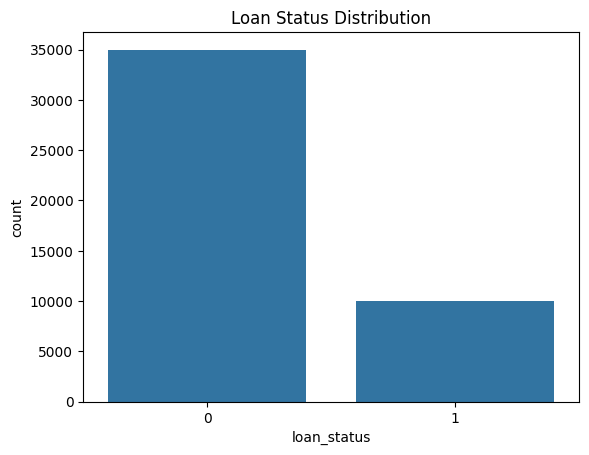

In [ ]:
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')

# 6 Correlation Heatmap

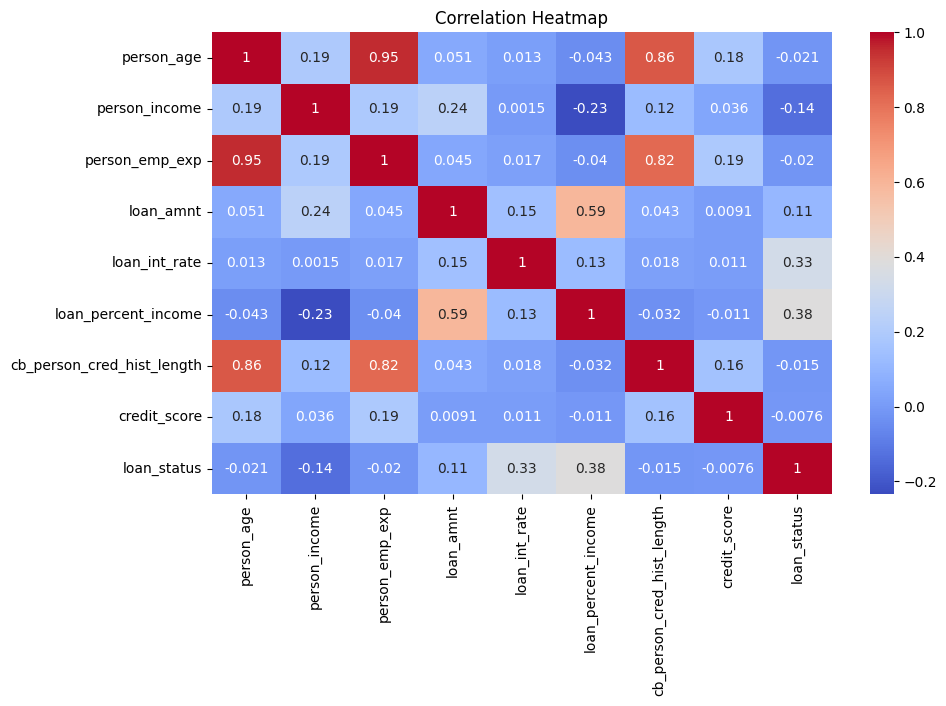

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# 7 Visualization

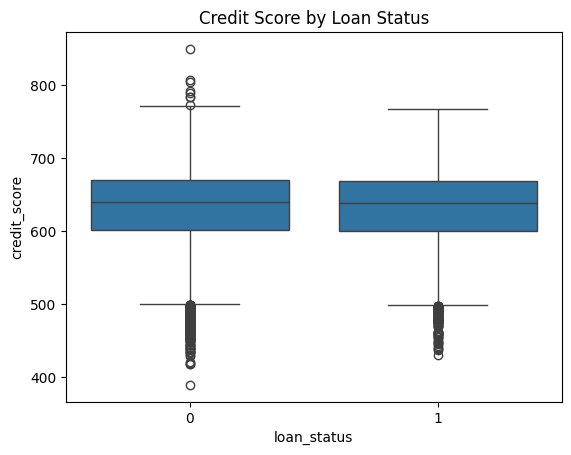

In [16]:
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title('Credit Score by Loan Status')
plt.show()

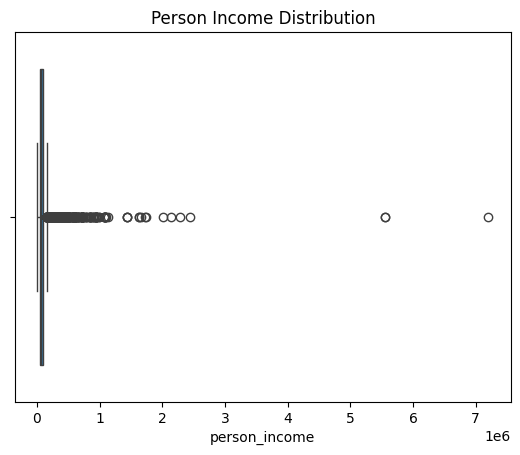

In [17]:
sns.boxplot(x='person_income', data=df)
plt.title('Person Income Distribution')
plt.show()

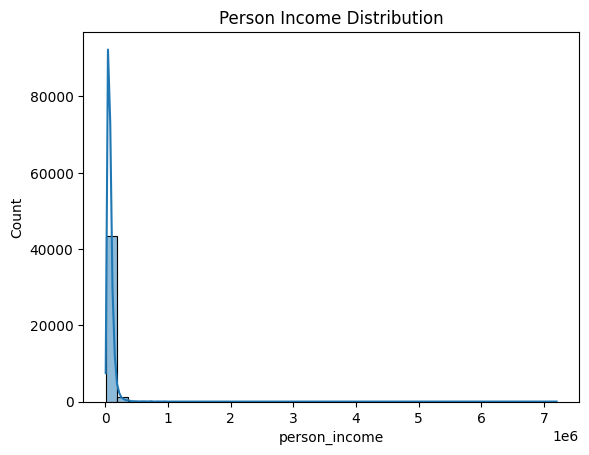

In [19]:
sns.histplot(df['person_income'], bins=40, kde=True)
plt.title('Person Income Distribution')
plt.show()

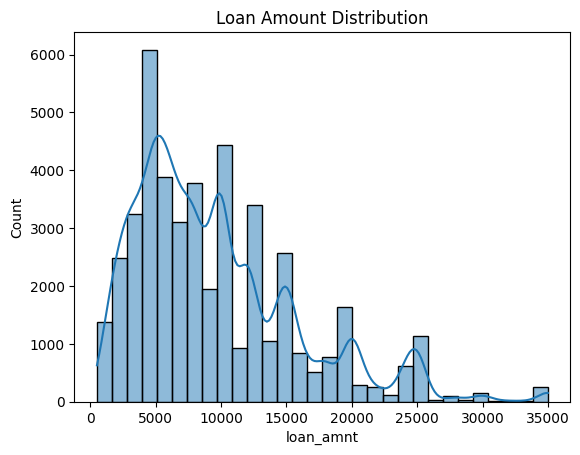

In [20]:
sns.histplot(df['loan_amnt'], bins=30, kde=True)
plt.title('Loan Amount Distribution')
plt.show()

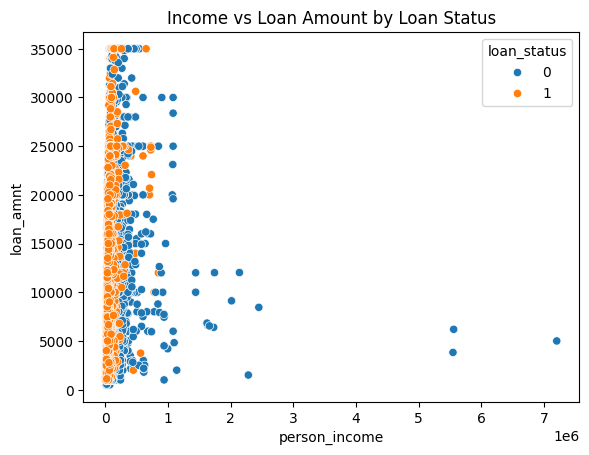

In [21]:
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=df)
plt.title('Income vs Loan Amount by Loan Status')
plt.show()

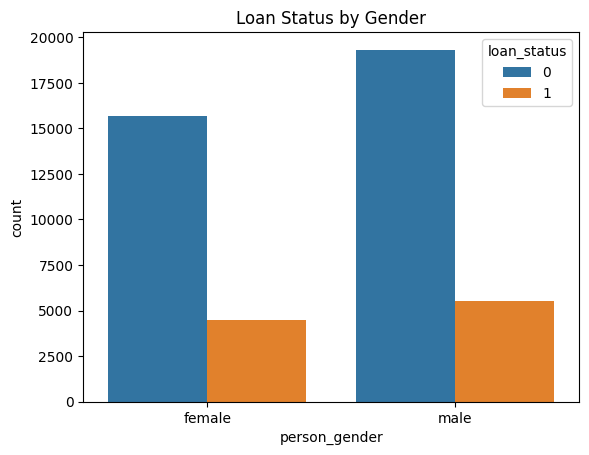

In [22]:
sns.countplot(x='person_gender', hue='loan_status', data=df)
plt.title('Loan Status by Gender')
plt.show()

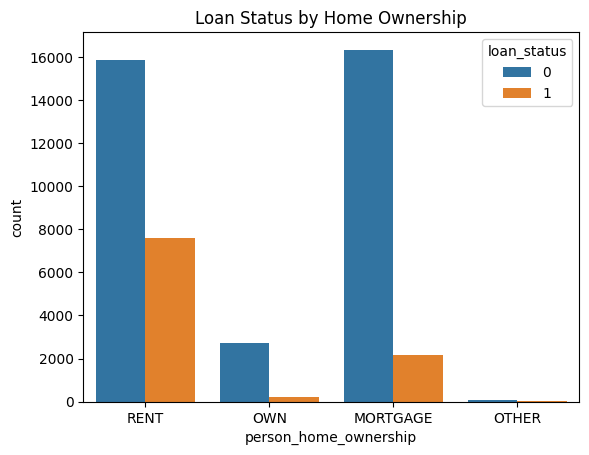

In [24]:
sns.countplot(x='person_home_ownership', hue='loan_status', data=df)
plt.title('Loan Status by Home Ownership')
plt.show()

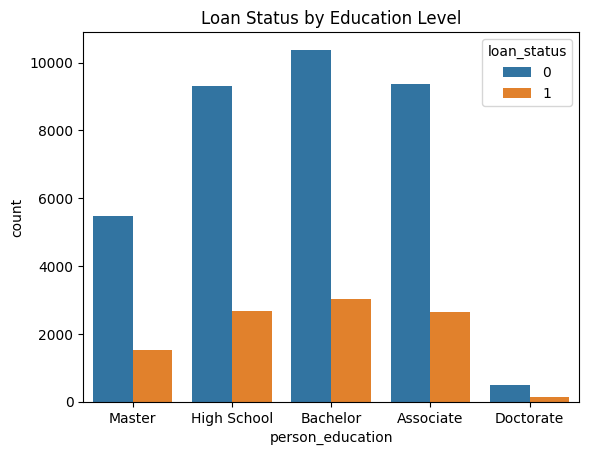

In [26]:
sns.countplot(x='person_education', hue='loan_status', data=df)
plt.title('Loan Status by Education Level')
plt.show()  

# Risk Sementation Analysis

In [ ]:
segment = df.groupby('income_segment', observed=False)['loan_status'].mean().reset_index()

# Feature Importance Preview

In [ ]:
df_model = pd.get_dummies(df, drop_first=True)

x = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

